# Agent 3 — Variants Comparison

In [129]:
import re, json, time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from groq import Groq

In [130]:
GROQ_API_KEY = "<YOUR_GROQ_API_KEY>"
groq_client  = Groq(api_key=GROQ_API_KEY)

DATA_DIR      = "FoodData_Central_sr_legacy_food_csv_2018-04"
KEY_NUTRIENTS = {1003: "protein", 1004: "fat", 1005: "carbs", 1008: "calories"}
MEAL_SPLITS   = {"breakfast": 0.25, "lunch": 0.35, "dinner": 0.30, "snack": 0.10}

VARIANTS = [
    {"name": "V1 — Deterministic", "temperature": 0.0, "color": "#4C72B0"},
    {"name": "V2 — Balanced",      "temperature": 0.4, "color": "#55A868"},
    {"name": "V3 — Creative",      "temperature": 0.9, "color": "#C44E52"},
]

In [131]:
def build_food_db():
    foods          = pd.read_csv(f"{DATA_DIR}/food.csv")
    food_nutrients = pd.read_csv(f"{DATA_DIR}/food_nutrient.csv")
    food_nutrients["nutrient_id"] = food_nutrients["nutrient_id"].astype(int)
    filtered = food_nutrients[food_nutrients["nutrient_id"].isin(KEY_NUTRIENTS)].copy()
    filtered["nutrient_name"] = filtered["nutrient_id"].map(KEY_NUTRIENTS)
    pivoted = filtered.pivot_table(
        index="fdc_id", columns="nutrient_name", values="amount", aggfunc="first"
    ).reset_index()
    df = pivoted.merge(foods[["fdc_id", "description"]], on="fdc_id")
    df = df.dropna(subset=["calories", "protein", "fat", "carbs"])
    df = df[df["calories"] > 0].reset_index(drop=True)
    df["food_name"] = df["description"].str.lower()
    return df[["food_name", "calories", "protein", "carbs", "fat"]]

class FoodDatabaseAgent:
    JUNK = ["baby", "candies", "candy", "instant", "dry mix", "formula", "infant"]

    def __init__(self, dataframe):
        self.df = dataframe.dropna(subset=["calories", "protein", "carbs", "fat"]).copy()

    def _best_match(self, matches):
        clean = matches[~matches["food_name"].str.contains(
            "|".join(self.JUNK), na=False
        )]
        pool = clean if not clean.empty else matches
        return pool.loc[pool["food_name"].str.len().idxmin()].to_dict()

    def get_food(self, name):
        name = name.lower().strip()
        matches = self.df[self.df["food_name"].str.contains(name, na=False, regex=False)]
        if not matches.empty:
            return self._best_match(matches)
        for word in name.split():
            if len(word) < 3:
                continue
            matches = self.df[self.df["food_name"].str.contains(word, na=False, regex=False)]
            if not matches.empty:
                return self._best_match(matches)
        return None

    def calculate_macros(self, name, grams):
        food = self.get_food(name)
        if not food:
            return None
        f = grams / 100
        return {
            "food_name": food["food_name"], "grams": grams,
            "calories": round(food["calories"] * f, 1),
            "protein":  round(food["protein"]  * f, 1),
            "carbs":    round(food["carbs"]    * f, 1),
            "fat":      round(food["fat"]      * f, 1)
        }

    def calculate_meal(self, items):
        total, details = {"calories": 0, "protein": 0, "carbs": 0, "fat": 0}, []
        for name, grams in items:
            m = self.calculate_macros(name, grams)
            if not m:
                continue
            details.append(m)
            for k in total:
                total[k] += m[k]
        return {"items": details, "macros": {k: round(v, 1) for k, v in total.items()}}

print("Loading food database...")
food_df = build_food_db()
food_db = FoodDatabaseAgent(food_df)
print(f"{len(food_df)} foods loaded")

Loading food database...
7756 foods loaded


In [132]:
class MealPlanAgent:

    def __init__(self, food_db, temperature=0.4):
        self.db          = food_db
        self.temperature = temperature

    def _build_prompt(self, targets, profile):
        cal, prot = targets["daily_calories"], targets["macros"]["protein_g"]
        fat, carbs = targets["macros"]["fat_g"], targets["macros"]["carbs_g"]
        splits_text = "\n".join(
            f"  - {meal}: {round(cal*pct)} kcal, {round(prot*pct)}g protein, "
            f"{round(fat*pct)}g fat, {round(carbs*pct)}g carbs"
            for meal, pct in MEAL_SPLITS.items()
        )
        example_format = (
            '{"breakfast": [{"food": "oats", "grams": 80}, {"food": "egg whites", "grams": 200}],'
            ' "lunch": [{"food": "chicken breast", "grams": 150}, {"food": "rice", "grams": 130}, {"food": "broccoli", "grams": 100}],'
            ' "dinner": [{"food": "turkey breast", "grams": 150}, {"food": "sweet potato", "grams": 150}, {"food": "asparagus", "grams": 100}],'
            ' "snack": [{"food": "banana", "grams": 100}, {"food": "greek yogurt", "grams": 150}]}'
        )
        return (
            f"You are a strict nutrition planner. Create a daily meal plan that EXACTLY hits the calorie and macro targets.\n\n"
            f"User: {profile.get('sex','male')}, {profile.get('weight_kg',70)}kg, "
            f"goal: {profile.get('goal','maintenance')}, diet: {profile.get('diet_type','balanced')}\n\n"
            f"DAILY TARGETS:\n"
            f"  Calories: {cal} kcal | Protein: {prot}g | Fat: {fat}g | Carbs: {carbs}g\n\n"
            f"Per meal budget:\n{splits_text}\n\n"
            f"Rules:\n"
            f"- Output ONLY valid JSON, no markdown\n"
            f"- Use lean whole foods: chicken breast, turkey, egg whites, oats, rice, potato, banana, greek yogurt, broccoli\n"
            f"- AVOID: peanut butter, nuts, oils, cheese, fatty fish, processed foods, candy, baby food\n"
            f"- Keep gram amounts realistic (max 300g per item). Each meal: 2-3 foods.\n\n"
            f"Format:\n{example_format}"
        )

    def _call_model(self, prompt):
        response = groq_client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[{"role": "user", "content": prompt}],
            temperature=self.temperature
        )
        return response.choices[0].message.content

    def _verify_meals(self, meal_json):
        verified = {}
        for meal, items in meal_json.items():
            if not isinstance(items, list):
                continue
            pairs = [(i["food"], i["grams"]) for i in items
                     if isinstance(i, dict) and "food" in i and "grams" in i]
            if pairs:
                verified[meal] = food_db.calculate_meal(pairs)
        return verified

    def _scale_to_target(self, verified, target_cal):
        achieved_cal = sum(m["macros"]["calories"] for m in verified.values())
        if achieved_cal == 0:
            return verified
        scale = target_cal / achieved_cal
        scaled = {}
        for meal_name, meal_data in verified.items():
            new_items = []
            for item in meal_data["items"]:
                recalc = food_db.calculate_macros(item["food_name"], round(item["grams"] * scale))
                if recalc:
                    new_items.append(recalc)
            total = {k: round(sum(i[k] for i in new_items), 1) for k in ["calories", "protein", "carbs", "fat"]}
            scaled[meal_name] = {"items": new_items, "macros": total}
        return scaled

    def generate(self, targets, profile):
        prompt    = self._build_prompt(targets, profile)
        raw_text  = self._call_model(prompt)
        raw       = re.sub(r"```json|```", "", raw_text).strip()
        m         = re.search(r'\{.*\}', raw, re.DOTALL)
        if m:
            raw = m.group(0)
        meal_json = json.loads(raw)
        verified  = self._verify_meals(meal_json)
        scaled    = self._scale_to_target(verified, targets["daily_calories"])
        total     = {k: round(sum(m["macros"][k] for m in scaled.values()), 1)
                     for k in ["calories", "protein", "carbs", "fat"]}
        return {"meals": scaled, "total_macros": total}

In [133]:
profile = {
    "age": 25, "sex": "male", "height_cm": 174, "weight_kg": 71,
    "activity_level": "active", "goal": "muscle_gain", "diet_type": "balanced"
}

targets = {
    "daily_calories": 3194,
    "macros": {"protein_g": 142, "fat_g": 89, "carbs_g": 457}
}

In [134]:
results   = {}
run_times = {}

for v in VARIANTS:
    print(f"Running {v['name']} ...")
    agent  = MealPlanAgent(food_db, temperature=v['temperature'])
    t0     = time.time()
    output = agent.generate(targets, profile)
    run_times[v['name']] = round(time.time() - t0, 2)
    results[v['name']]   = output
    t = output['total_macros']
    print(f"  → {t['calories']} kcal | P:{t['protein']}g F:{t['fat']}g C:{t['carbs']}g  [{run_times[v['name']]}s]")

print('\nAll 3 variants done.')

Running V1 — Deterministic ...
  → 3198.8 kcal | P:181.4g F:68.6g C:519.6g  [0.65s]
Running V2 — Balanced ...
  → 3195.1 kcal | P:182.9g F:84.4g C:475.3g  [0.5s]
Running V3 — Creative ...
  → 3191.0 kcal | P:113.4g F:114.4g C:428.8g  [0.37s]

All 3 variants done.


In [135]:
rows = []
tgt  = targets["macros"]

rows.append({
    "Variant":      "TARGET",
    "Temp":         "—",
    "Calories":     targets["daily_calories"],
    "Protein (g)":  tgt["protein_g"],
    "Fat (g)":      tgt["fat_g"],
    "Carbs (g)":    tgt["carbs_g"],
    "Cal Error %":  "—",
    "Unique Foods": "—",
})

for v in VARIANTS:
    name   = v["name"]
    result = results[name]
    total  = result["total_macros"]
    all_foods = [
        item["food_name"]
        for meal_data in result["meals"].values()
        for item in meal_data["items"]
    ]
    unique_foods = len(set(all_foods))
    cal_err = round(abs(total["calories"] - targets["daily_calories"]) / targets["daily_calories"] * 100, 1)
    rows.append({
        "Variant":      name,
        "Temp":         v["temperature"],
        "Calories":     total["calories"],
        "Protein (g)":  total["protein"],
        "Fat (g)":      total["fat"],
        "Carbs (g)":    total["carbs"],
        "Cal Error %":  f"{cal_err}%",
        "Unique Foods": unique_foods,
    })

df_compare = pd.DataFrame(rows).set_index("Variant")
df_compare

,Temp,Calories,Protein (g),Fat (g),Carbs (g),Cal Error %,Unique Foods
Variant,,,,,,,
TARGET,—,3194.0,142.0,89.0,457.0,—,—
V1 — Deterministic,0.0,3198.8,181.4,68.6,519.6,0.2%,10
V2 — Balanced,0.4,3195.1,182.9,84.4,475.3,0.0%,10
V3 — Creative,0.9,3191.0,113.4,114.4,428.8,0.1%,10


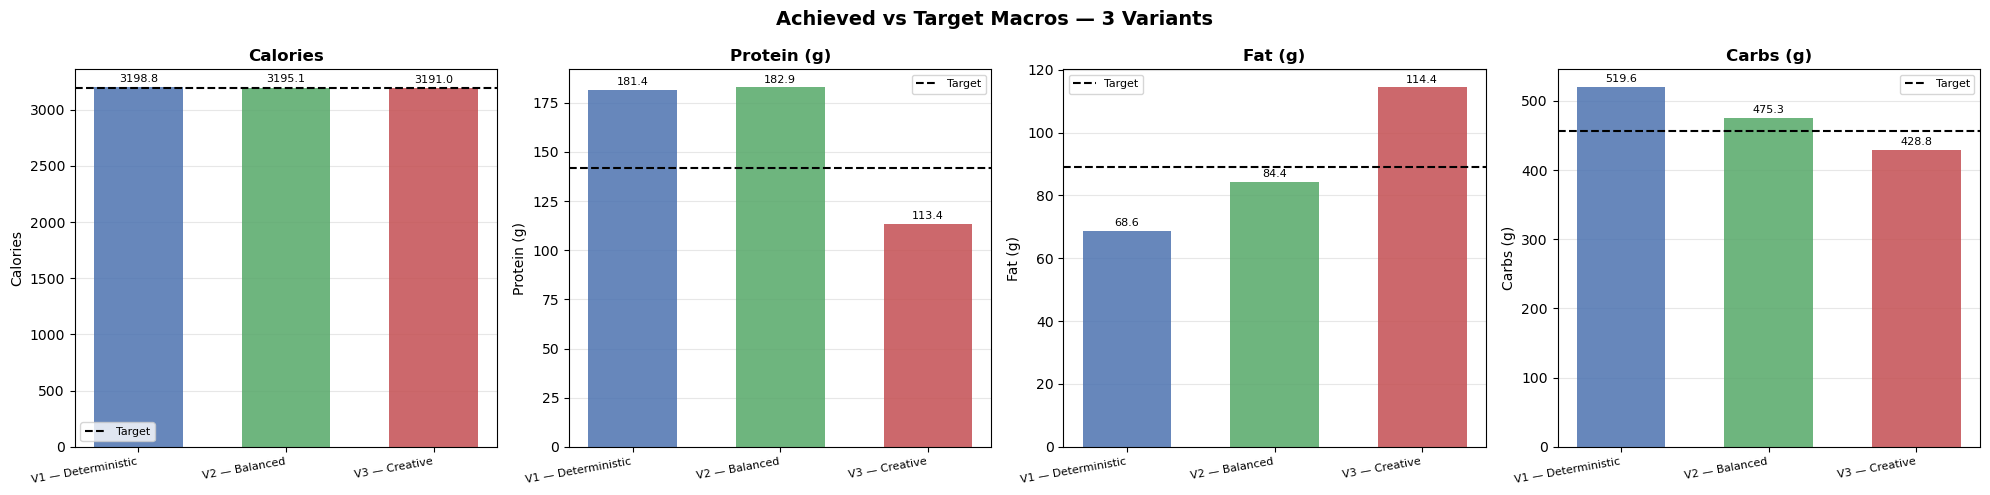

In [136]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Achieved vs Target Macros — 3 Variants", fontsize=14, fontweight="bold")

metrics = [
    ("Calories",    targets["daily_calories"], "calories"),
    ("Protein (g)", tgt["protein_g"],          "protein"),
    ("Fat (g)",     tgt["fat_g"],              "fat"),
    ("Carbs (g)",   tgt["carbs_g"],            "carbs"),
]

labels = [v["name"] for v in VARIANTS]
colors = [v["color"] for v in VARIANTS]
x      = np.arange(len(VARIANTS))

for ax, (label, target_val, key) in zip(axes, metrics):
    achieved = [results[v["name"]]["total_macros"][key] for v in VARIANTS]
    bars = ax.bar(x, achieved, color=colors, alpha=0.85, width=0.6, zorder=2)
    ax.axhline(target_val, color="black", linewidth=1.5, linestyle="--", label="Target", zorder=3)
    ax.set_title(label, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8, rotation=10, ha="right")
    ax.set_ylabel(label)
    ax.grid(axis="y", alpha=0.3, zorder=1)
    for bar, val in zip(bars, achieved):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + target_val*0.01,
                str(val), ha="center", va="bottom", fontsize=8)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("variant_macros.png", dpi=150, bbox_inches="tight")
plt.show()

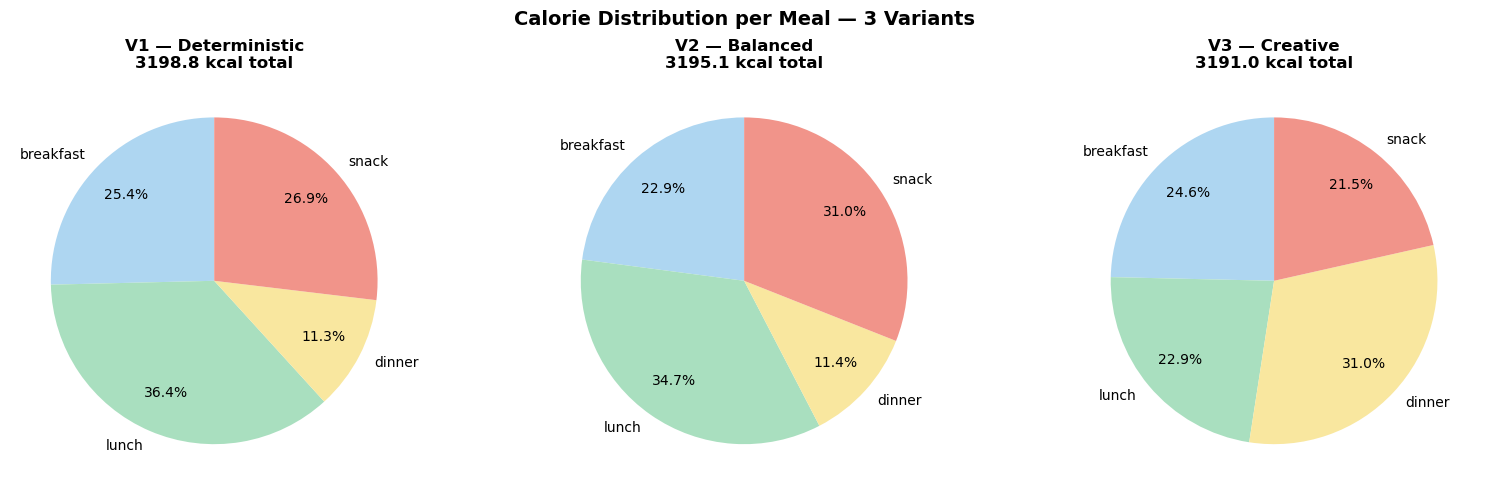

In [137]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Calorie Distribution per Meal — 3 Variants", fontsize=14, fontweight="bold")

meal_names  = list(MEAL_SPLITS.keys())
meal_colors = ["#AED6F1", "#A9DFBF", "#F9E79F", "#F1948A"]

for ax, v in zip(axes, VARIANTS):
    meal_cals = [
        results[v["name"]]["meals"].get(m, {}).get("macros", {}).get("calories", 0)
        for m in meal_names
    ]
    ax.pie(meal_cals, labels=meal_names, colors=meal_colors,
           autopct="%1.1f%%", startangle=90, pctdistance=0.75)
    total_cal = sum(meal_cals)
    ax.set_title(f"{v['name']}\n{total_cal} kcal total", fontweight="bold")

plt.tight_layout()
plt.savefig("variant_meal_dist.png", dpi=150, bbox_inches="tight")
plt.show()

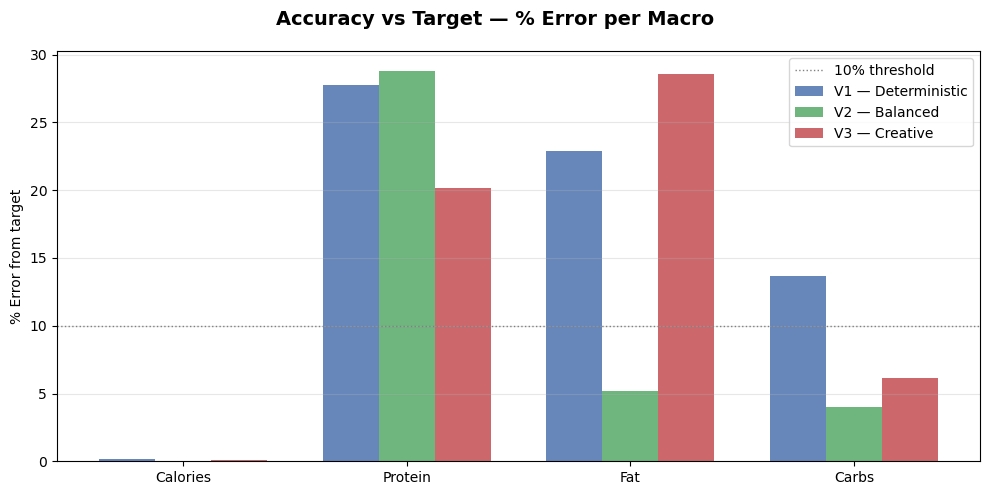

In [138]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Accuracy vs Target — % Error per Macro", fontsize=14, fontweight="bold")

macro_keys   = ["calories", "protein", "fat", "carbs"]
macro_labels = ["Calories", "Protein", "Fat", "Carbs"]
target_vals  = [targets["daily_calories"], tgt["protein_g"], tgt["fat_g"], tgt["carbs_g"]]

x     = np.arange(len(macro_labels))
width = 0.25

for i, v in enumerate(VARIANTS):
    errors = [
        abs(results[v["name"]]["total_macros"][k] - tgt_val) / tgt_val * 100
        for k, tgt_val in zip(macro_keys, target_vals)
    ]
    ax.bar(x + i*width, errors, width, label=v["name"], color=v["color"], alpha=0.85)

ax.axhline(10, color="grey", linestyle=":", linewidth=1, label="10% threshold")
ax.set_xticks(x + width)
ax.set_xticklabels(macro_labels)
ax.set_ylabel("% Error from target")
ax.set_ylim(0, None)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("variant_errors.png", dpi=150, bbox_inches="tight")
plt.show()

In [139]:
for v in VARIANTS:
    print(f"\n{'='*55}")
    print(f"  {v['name']} (temp={v['temperature']})")
    print(f"{'='*55}")
    for meal_name, meal_data in results[v["name"]]["meals"].items():
        m = meal_data["macros"]
        print(f"  {meal_name.upper()} — {m['calories']} kcal | P:{m['protein']}g F:{m['fat']}g C:{m['carbs']}g")
        for item in meal_data["items"]:
            print(f"    · {item['food_name']} ({item['grams']}g)")
    total = results[v["name"]]["total_macros"]
    print(f"  DAY: {total['calories']} kcal | P:{total['protein']}g F:{total['fat']}g C:{total['carbs']}g")


  V1 — Deterministic (temp=0.0)
  BREAKFAST — 811.8 kcal | P:29.3g F:16.3g C:148.3g
    · buckwheat groats, roasted, dry (120g)
    · eggnog (299g)
    · bananas, raw (150g)
  LUNCH — 1163.7 kcal | P:56.5g F:27.6g C:175.1g
    · chicken breast, roll, oven-roasted (225g)
    · rice crackers (195g)
    · broccoli, raw (150g)
  DINNER — 363.0 kcal | P:42.2g F:9.8g C:30.6g
    · turkey breast, sliced, prepackaged (225g)
    · sweet potato leaves, raw (225g)
    · asparagus, raw (150g)
  SNACK — 860.3 kcal | P:53.4g F:14.9g C:165.6g
    · bananas, raw (150g)
    · spices, fenugreek seed (225g)
  DAY: 3198.8 kcal | P:181.4g F:68.6g C:519.6g

  V2 — Balanced (temp=0.4)
  BREAKFAST — 732.4 kcal | P:27.4g F:15.3g C:130.9g
    · buckwheat groats, roasted, dry (114g)
    · eggnog (284g)
    · bananas, raw (99g)
  LUNCH — 1108.6 kcal | P:54.3g F:26.1g C:167.2g
    · chicken breast, roll, oven-roasted (213g)
    · rice crackers (184g)
    · broccoli, raw (170g)
  DINNER — 363.6 kcal | P:40.8g F:9.

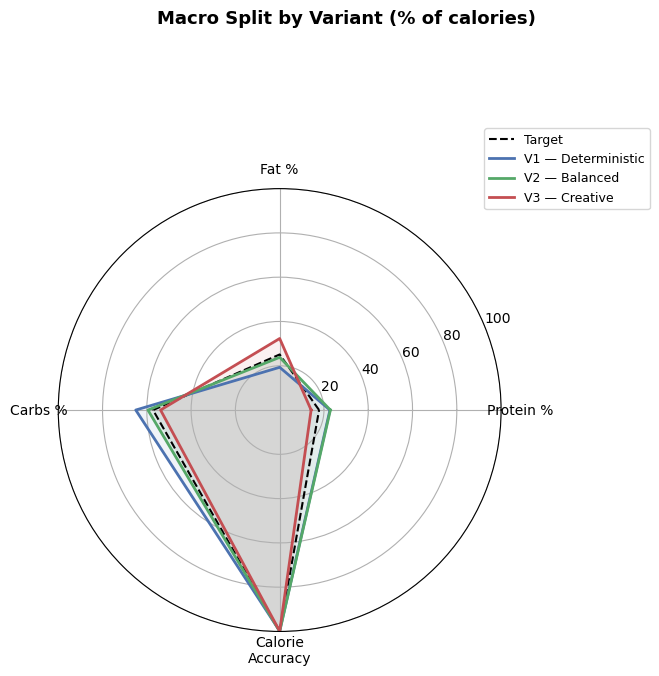

In [140]:
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.suptitle("Macro Split by Variant (% of calories)", fontsize=13, fontweight="bold", y=1.02)

categories = ["Protein %", "Fat %", "Carbs %", "Calorie\nAccuracy"]
N          = len(categories)
angles     = [n / float(N) * 2 * np.pi for n in range(N)]
angles    += angles[:1]

tgt_prot_pct = round(targets["macros"]["protein_g"] * 4 / targets["daily_calories"] * 100, 1)
tgt_fat_pct  = round(targets["macros"]["fat_g"]     * 9 / targets["daily_calories"] * 100, 1)
tgt_carb_pct = round(targets["macros"]["carbs_g"]   * 4 / targets["daily_calories"] * 100, 1)
target_vals  = [tgt_prot_pct, tgt_fat_pct, tgt_carb_pct, 100] + [tgt_prot_pct]

ax.plot(angles, target_vals, "k--", linewidth=1.5, label="Target")
ax.fill(angles, target_vals, alpha=0.05, color="black")

for v in VARIANTS:
    t     = results[v["name"]]["total_macros"]
    p_pct = round(t["protein"] * 4 / t["calories"] * 100, 1)
    f_pct = round(t["fat"]     * 9 / t["calories"] * 100, 1)
    c_pct = round(t["carbs"]   * 4 / t["calories"] * 100, 1)
    acc   = max(0, 100 - abs(t["calories"] - targets["daily_calories"]) / targets["daily_calories"] * 100)
    vals  = [p_pct, f_pct, c_pct, round(acc, 1)] + [p_pct]
    ax.plot(angles, vals, linewidth=2, color=v["color"], label=v["name"])
    ax.fill(angles, vals, alpha=0.08, color=v["color"])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 100)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig("variant_radar.png", dpi=150, bbox_inches="tight")
plt.show()

## Additional Charts

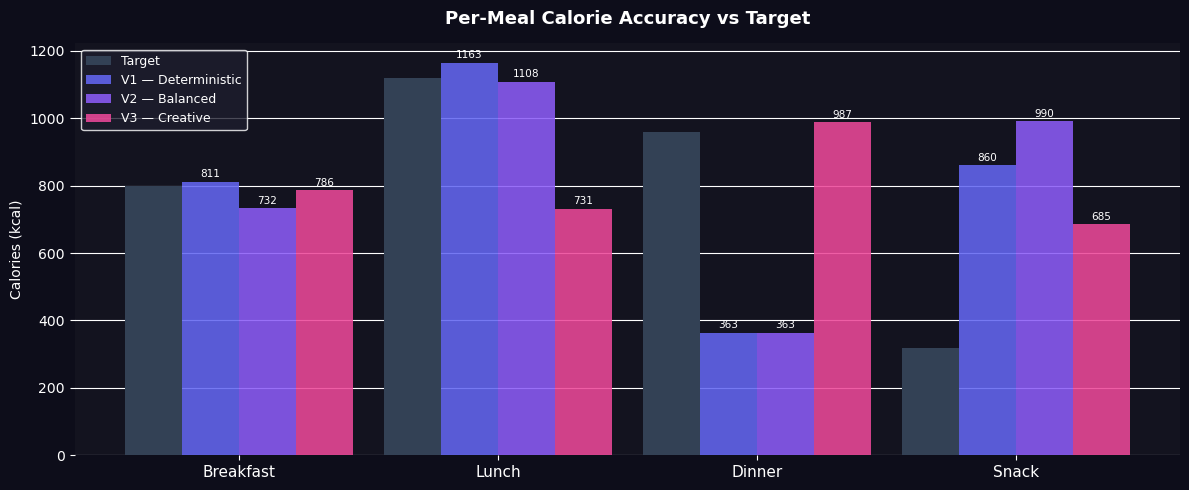

Saved: variant_meal_accuracy.png


In [141]:
MEAL_SPLITS  = {'breakfast': 0.25, 'lunch': 0.35, 'dinner': 0.30, 'snack': 0.10}
meal_names   = list(MEAL_SPLITS.keys())
tgt_cal      = targets['daily_calories']
meal_targets = {m: round(tgt_cal * p) for m, p in MEAL_SPLITS.items()}

x      = np.arange(len(meal_names))
width  = 0.22
colors = ['#6366f1', '#8b5cf6', '#ec4899']

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0d0d1a')
ax.set_facecolor('#13131f')

ax.bar(x - width*1.5, [meal_targets[m] for m in meal_names],
       width, label='Target', color='#334155', zorder=3)

for i, (v, col) in enumerate(zip(VARIANTS, colors)):
    achieved = [results[v['name']]['meals'].get(m, {}).get('macros', {}).get('calories', 0)
                for m in meal_names]
    bars = ax.bar(x + (i - 0.5)*width, achieved, width,
                  label=v['name'], color=col, alpha=0.88, zorder=3)
    for bar, val in zip(bars, achieved):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                f'{int(val)}', ha='center', va='bottom', fontsize=7.5,
                color='white', fontweight='500')

ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in meal_names], color='white', fontsize=11)
ax.set_ylabel('Calories (kcal)', color='white')
ax.set_title('Per-Meal Calorie Accuracy vs Target', color='white', fontsize=13, fontweight='bold', pad=14)
ax.tick_params(colors='white')
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.yaxis.grid(True, color=(1.000, 1.000, 1.000, 0.06), zorder=0)
ax.set_axisbelow(True)
ax.legend(facecolor='#1e1e2e', edgecolor=(1.000, 1.000, 1.000, 0.1), labelcolor='white', fontsize=9)
plt.tight_layout()
plt.savefig('variant_meal_accuracy.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print('Saved: variant_meal_accuracy.png')

Foods shared by ALL 3 variants : 2 → {'bananas, raw', 'turkey breast,'}
Unique to V1 — Deterministic       : 1 → {'asparagus, raw'}
Unique to V2 — Balanced            : 1 → {'scrapple, pork'}
Unique to V3 — Creative            : 8 → {'mushrooms, portabella,', 'stew, steamed', 'bread, oatmeal', 'honey', 'croutons, plain', 'crackers, gluten-free,', 'taco shells,', 'fast foods,'}


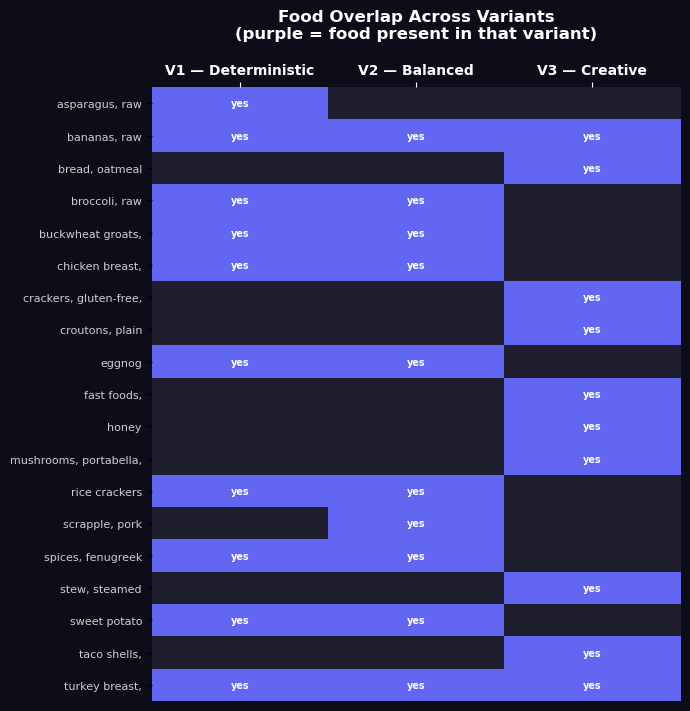

Saved: variant_food_overlap.png


In [142]:
def food_set(variant_name):
    foods = set()
    for meal_data in results[variant_name]['meals'].values():
        for item in meal_data['items']:
            name = ' '.join(item['food_name'].split()[:2])
            foods.add(name)
    return foods

vnames    = [v['name'] for v in VARIANTS]
sets      = {n: food_set(n) for n in vnames}
all_foods = sorted(set.union(*sets.values()))

matrix     = [[1 if f in sets[v] else 0 for v in vnames] for f in all_foods]
matrix_arr = np.array(matrix, dtype=float)

fig, ax = plt.subplots(figsize=(7, max(5, len(all_foods) * 0.38)))
fig.patch.set_facecolor('#0d0d1a')
ax.set_facecolor('#13131f')

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('nutriai', ['#1e1e2e', '#6366f1'])
ax.imshow(matrix_arr, cmap=cmap, aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(vnames)))
ax.set_xticklabels(vnames, color='white', fontsize=10, fontweight='600')
ax.set_yticks(range(len(all_foods)))
ax.set_yticklabels(all_foods, color=(1.000, 1.000, 1.000, 0.8), fontsize=8)
ax.tick_params(axis='x', top=True, bottom=False, labeltop=True, labelbottom=False, colors='white')
ax.spines[['top','right','left','bottom']].set_visible(False)

for i, row in enumerate(matrix):
    for j, val in enumerate(row):
        ax.text(j, i, 'yes' if val else '', ha='center', va='center',
                fontsize=7, color='white', fontweight='600')

ax.set_title('Food Overlap Across Variants\n(purple = food present in that variant)',
             color='white', fontsize=12, fontweight='bold', pad=18)

shared_all = sets[vnames[0]] & sets[vnames[1]] & sets[vnames[2]]
unique     = {v: sets[v] - set.union(*[sets[u] for u in vnames if u != v]) for v in vnames}

print(f'Foods shared by ALL 3 variants : {len(shared_all)} → {shared_all or "none"}')
for v in vnames:
    print(f'Unique to {v:25s}: {len(unique[v])} → {unique[v] or "none"}')

plt.tight_layout()
plt.savefig('variant_food_overlap.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print('Saved: variant_food_overlap.png')

Fastest : V3 — Creative (0.37s)
Slowest : V1 — Deterministic (0.65s)
Difference: 0.28s (75.7% slower)


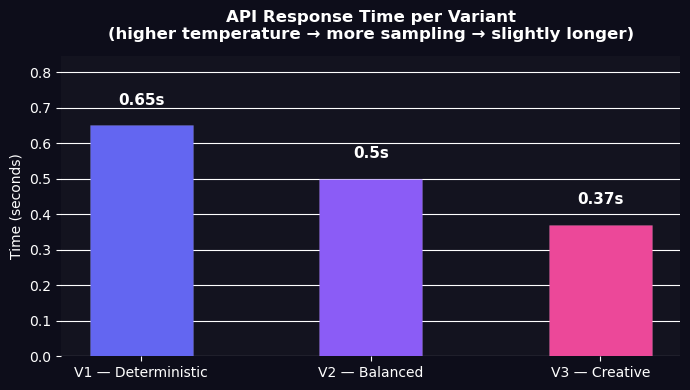

Saved: variant_response_time.png


In [143]:
vnames = [v['name'] for v in VARIANTS]
times  = [run_times[v] for v in vnames]
colors = ['#6366f1', '#8b5cf6', '#ec4899']

fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor('#0d0d1a')
ax.set_facecolor('#13131f')

bars = ax.bar(vnames, times, color=colors, width=0.45,
              edgecolor=(1.000, 1.000, 1.000, 0.1), linewidth=0.8, zorder=3)

for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{t}s', ha='center', va='bottom', fontsize=11,
            color='white', fontweight='600')

ax.set_ylabel('Time (seconds)', color='white', fontsize=10)
ax.set_title('API Response Time per Variant\n(higher temperature → more sampling → slightly longer)',
             color='white', fontsize=12, fontweight='bold', pad=12)
ax.tick_params(colors='white', labelsize=10)
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.yaxis.grid(True, color=(1.000, 1.000, 1.000, 0.06), zorder=0)
ax.set_axisbelow(True)
ax.set_ylim(0, max(times) * 1.3)

fastest = vnames[times.index(min(times))]
slowest = vnames[times.index(max(times))]
diff    = round(max(times) - min(times), 2)
print(f'Fastest : {fastest} ({min(times)}s)')
print(f'Slowest : {slowest} ({max(times)}s)')
print(f'Difference: {diff}s ({round(diff/min(times)*100,1)}% slower)')

plt.tight_layout()
plt.savefig('variant_response_time.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print('Saved: variant_response_time.png')

In [144]:
def analyse_variants(results, targets):
    tgt_cal   = targets["daily_calories"]
    tgt_prot  = targets["macros"]["protein_g"]
    tgt_fat   = targets["macros"]["fat_g"]
    tgt_carbs = targets["macros"]["carbs_g"]

    print(f"{'='*65}")
    print(f"  VARIANT ANALYSIS")
    print(f"{'='*65}")

    summaries = {}
    for v in VARIANTS:
        name   = v["name"]
        total  = results[name]["total_macros"]
        meals  = results[name]["meals"]

        cal_err   = total["calories"] - tgt_cal
        prot_diff = total["protein"]  - tgt_prot
        fat_diff  = total["fat"]      - tgt_fat
        carb_diff = total["carbs"]    - tgt_carbs

        all_foods    = [item["food_name"] for m in meals.values() for item in m["items"]]
        unique       = len(set(all_foods))
        biggest_meal = max(meals, key=lambda m: meals[m]["macros"]["calories"])
        prot_density = round(total["protein"] / total["calories"] * 100, 1)
        fat_pct      = round(total["fat"]     * 9 / total["calories"] * 100, 1)
        prot_pct     = round(total["protein"] * 4 / total["calories"] * 100, 1)
        carb_pct     = round(total["carbs"]   * 4 / total["calories"] * 100, 1)

        summaries[name] = {
            "cal_err": cal_err, "prot_diff": prot_diff,
            "fat_diff": fat_diff, "carb_diff": carb_diff,
            "unique": unique, "biggest_meal": biggest_meal,
            "prot_density": prot_density,
            "fat_pct": fat_pct, "prot_pct": prot_pct, "carb_pct": carb_pct
        }

        focus = []
        if prot_diff > 10:
            focus.append(f"high-protein (+{round(prot_diff)}g over target)")
        elif prot_diff < -10:
            focus.append(f"low-protein ({round(prot_diff)}g under target)")
        if fat_diff > 10:
            focus.append(f"high-fat (+{round(fat_diff)}g over target)")
        elif fat_diff < -10:
            focus.append(f"low-fat ({round(abs(fat_diff))}g under target — lean foods)")
        if carb_diff > 30:
            focus.append(f"carb-heavy (+{round(carb_diff)}g over target)")
        elif carb_diff < -30:
            focus.append(f"low-carb ({round(abs(carb_diff))}g under target)")

        consistency = "deterministic (same result every run)" if v["temperature"] == 0.0 \
                      else "slightly varied per run" if v["temperature"] <= 0.4 \
                      else "creative — different result each run"

        print(f"\n{name}  (temp={v['temperature']})")
        print(f"  Behaviour  : {consistency}")
        print(f"  Macro focus: {', '.join(focus) if focus else 'balanced — close to all targets'}")
        print(f"  Macro split: {prot_pct}% protein  |  {fat_pct}% fat  |  {carb_pct}% carbs")
        print(f"  Protein density : {prot_density}g protein per 100 kcal")
        print(f"  Food variety    : {unique} unique foods across the day")
        print(f"  Heaviest meal   : {biggest_meal} ({round(meals[biggest_meal]['macros']['calories'])} kcal)")
        print(f"  Calorie accuracy: {round(abs(cal_err)/tgt_cal*100, 1)}% error "
              f"({'over' if cal_err > 0 else 'under'} by {round(abs(cal_err))} kcal)")

    print(f"\n{'='*65}")
    print("  WINNER PER METRIC")
    print(f"{'='*65}")

    names      = [v["name"] for v in VARIANTS]
    best_cal   = min(names, key=lambda n: abs(summaries[n]["cal_err"]))
    most_prot  = max(names, key=lambda n: results[n]["total_macros"]["protein"])
    most_var   = max(names, key=lambda n: summaries[n]["unique"])
    lowest_fat = min(names, key=lambda n: results[n]["total_macros"]["fat"])

    print(f"  Best calorie accuracy : {best_cal}")
    print(f"  Most protein          : {most_prot}")
    print(f"  Most food variety     : {most_var}")
    print(f"  Leanest (lowest fat)  : {lowest_fat}")

analyse_variants(results, targets)

  VARIANT ANALYSIS

V1 — Deterministic  (temp=0.0)
  Behaviour  : deterministic (same result every run)
  Macro focus: high-protein (+39g over target), low-fat (20g under target — lean foods), carb-heavy (+63g over target)
  Macro split: 22.7% protein  |  19.3% fat  |  65.0% carbs
  Protein density : 5.7g protein per 100 kcal
  Food variety    : 10 unique foods across the day
  Heaviest meal   : lunch (1164 kcal)
  Calorie accuracy: 0.2% error (over by 5 kcal)

V2 — Balanced  (temp=0.4)
  Behaviour  : slightly varied per run
  Macro focus: high-protein (+41g over target)
  Macro split: 22.9% protein  |  23.8% fat  |  59.5% carbs
  Protein density : 5.7g protein per 100 kcal
  Food variety    : 10 unique foods across the day
  Heaviest meal   : lunch (1109 kcal)
  Calorie accuracy: 0.0% error (over by 1 kcal)

V3 — Creative  (temp=0.9)
  Behaviour  : creative — different result each run
  Macro focus: low-protein (-29g under target), high-fat (+25g over target)
  Macro split: 14.2% prot